# Tag 08 - Fortgeschrittene
## DBSCAN & Silhouette Coefficient

In [2]:
OUTPUT_SUBDIR = "02_fortgeschrittene"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [3]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
while PROJECT_DIR.name != "Tag_08_Clustering_Project" and PROJECT_DIR.parent != PROJECT_DIR:
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data" / "raw"
OUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_SUBDIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)

PROJECT_DIR: c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_08_Clustering_Project
DATA_DIR: c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_08_Clustering_Project\data\raw
OUT_DIR: c:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_08_Clustering_Project\outputs\02_fortgeschrittene


In [4]:
possible_files = [
    "Online Retail.xlsx", "Online_Retail.xlsx", "online_retail.xlsx",
    "Online Retail.csv", "Online_Retail.csv", "online_retail.csv"
]
DATA_PATH = next((DATA_DIR / f for f in possible_files if (DATA_DIR / f).exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Put Online Retail data in {DATA_DIR}. Accepted names: {possible_files}")

if DATA_PATH.suffix.lower() in [".xlsx", ".xls"]:
    retail = pd.read_excel(DATA_PATH)
else:
    retail = pd.read_csv(DATA_PATH, encoding="latin1")

retail.columns = retail.columns.astype(str).str.strip()

retail = retail.rename(columns={
    "Customer ID": "CustomerID",
    "CustomerID": "CustomerID",
    "Invoice": "InvoiceNo",
    "InvoiceNo": "InvoiceNo",
    "Invoice Date": "InvoiceDate",
    "InvoiceDate": "InvoiceDate",
    "Price": "UnitPrice",
    "UnitPrice": "UnitPrice"
})

print("Using file:", DATA_PATH.name)
print("Shape:", retail.shape)
print("Columns:", retail.columns.tolist())
retail.head()


Using file: Online_Retail.xlsx
Shape: (525461, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
required_cols = ["CustomerID", "InvoiceNo", "InvoiceDate", "Quantity", "UnitPrice"]
missing = [c for c in required_cols if c not in retail.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}\nAvailable columns: {list(retail.columns)}")

retail = retail.dropna(subset=["CustomerID", "InvoiceDate", "InvoiceNo", "Quantity", "UnitPrice"]).copy()
retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"], errors="coerce")
retail["Quantity"] = pd.to_numeric(retail["Quantity"], errors="coerce")
retail["UnitPrice"] = pd.to_numeric(retail["UnitPrice"], errors="coerce")
retail = retail.dropna(subset=["InvoiceDate", "Quantity", "UnitPrice"])
retail = retail[(retail["Quantity"] > 0) & (retail["UnitPrice"] > 0)].copy()
retail["TotalPrice"] = retail["Quantity"] * retail["UnitPrice"]
retail["CustomerID"] = retail["CustomerID"].astype(str)
print(retail.shape)
retail.head()


(407664, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [6]:
snapshot_date = retail["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = retail.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

rfm = rfm[(rfm["Frequency"] > 0) & (rfm["Monetary"] > 0)].copy()
rfm.to_csv(OUT_DIR / "intermediate_rfm_raw.csv", index=False)
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [7]:
features = ["Recency", "Frequency", "Monetary"]
scaler = StandardScaler()
X_rfm = scaler.fit_transform(rfm[features])
X_rfm_df = pd.DataFrame(X_rfm, columns=features)
X_rfm_df.to_csv(OUT_DIR / "intermediate_rfm_scaled.csv", index=False)
X_rfm_df.describe()

,Recency,Frequency,Monetary
count,4.312000e+03,4.312000e+03,4.312000e+03
mean,5.602610e-17,5.932175e-17,-2.306957e-17
std,1.000116e+00,1.000116e+00,1.000116e+00
min,-9.310522e-01,-4.230129e-01,-2.294610e-01
25%,-7.555219e-01,-4.230129e-01,-1.952388e-01
50%,-3.941361e-01,-3.006029e-01,-1.505835e-01
75%,4.628645e-01,6.662716e-02,-3.647250e-02
max,2.920288e+00,2.454863e+01,3.894297e+01


In [8]:
dbscan_rows = []
best_dbscan = None
best_dbscan_score = -1

for eps in [0.5, 1.0, 2.0]:
    for ms in [3, 5, 10]:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_rfm)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        score = np.nan
        mask = labels != -1
        if n_clusters >= 2 and mask.sum() > n_clusters:
            score = silhouette_score(X_rfm[mask], labels[mask])
            if score > best_dbscan_score:
                best_dbscan_score = score
                best_dbscan = {"eps": eps, "min_samples": ms, "labels": labels, "silhouette": score}
        dbscan_rows.append({"eps": eps, "min_samples": ms, "n_clusters": n_clusters, "n_noise": n_noise, "silhouette_without_noise": score})

DBSCAN_RESULTS = pd.DataFrame(dbscan_rows)
DBSCAN_RESULTS.to_csv(OUT_DIR / "intermediate_dbscan_grid_results.csv", index=False)
DBSCAN_RESULTS

,eps,min_samples,n_clusters,n_noise,silhouette_without_noise
0,0.5,3,6,48,0.379685
1,0.5,5,3,63,0.615258
2,0.5,10,1,87,NaN
3,1.0,3,2,27,0.811601
4,1.0,5,1,32,NaN
5,1.0,10,1,38,NaN
6,2.0,3,2,14,0.845690
7,2.0,5,1,17,NaN
8,2.0,10,1,22,NaN


In [9]:
kmeans_rows = []
best_kmeans = None
best_kmeans_score = -1

for k in range(2, 9):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_rfm)
    score = silhouette_score(X_rfm, labels)
    kmeans_rows.append({"k": k, "silhouette": score})
    if score > best_kmeans_score:
        best_kmeans_score = score
        best_kmeans = {"k": k, "labels": labels, "silhouette": score}

KMEANS_RESULTS = pd.DataFrame(kmeans_rows)
KMEANS_RESULTS.to_csv(OUT_DIR / "intermediate_kmeans_silhouette_results.csv", index=False)
KMEANS_RESULTS

,k,silhouette
0,2,0.931399
1,3,0.589034
2,4,0.611325
3,5,0.613943
4,6,0.505866
5,7,0.492969
6,8,0.497304


In [10]:
comparison = pd.DataFrame([
    {"method": f"K-Means k={best_kmeans['k']}", "silhouette": best_kmeans["silhouette"], "notes": "all points"},
    {"method": f"DBSCAN eps={best_dbscan['eps']} min_samples={best_dbscan['min_samples']}" if best_dbscan else "DBSCAN", "silhouette": best_dbscan["silhouette"] if best_dbscan else np.nan, "notes": "noise excluded" if best_dbscan else "no valid clustering"}
])
comparison.to_csv(OUT_DIR / "intermediate_silhouette_comparison.csv", index=False)
comparison

,method,silhouette,notes
0,K-Means k=2,0.931399,all points
1,DBSCAN eps=2.0 min_samples=3,0.845690,noise excluded


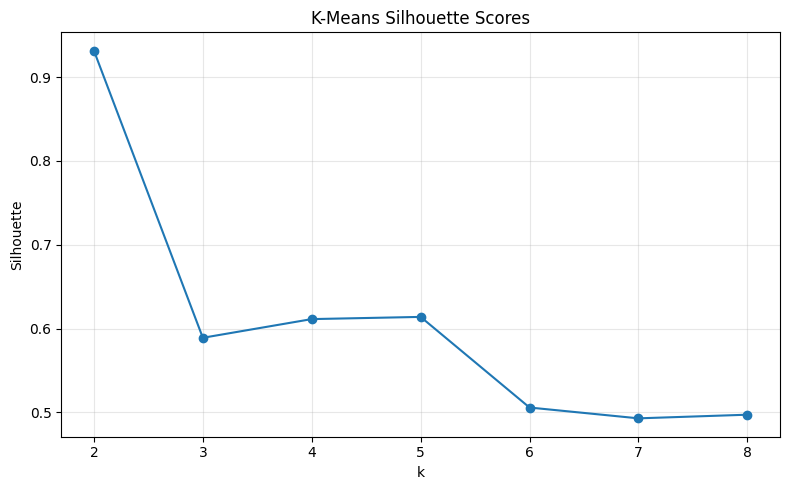

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(KMEANS_RESULTS["k"], KMEANS_RESULTS["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("K-Means Silhouette Scores")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "intermediate_kmeans_silhouette_curve.png", dpi=160)
plt.show()

if best_dbscan:
    rfm_out = rfm.copy()
    rfm_out["dbscan_label"] = best_dbscan["labels"]
    rfm_out["kmeans_label"] = best_kmeans["labels"]
    rfm_out.to_csv(OUT_DIR / "intermediate_rfm_with_cluster_labels.csv", index=False)